In [15]:
%matplotlib notebook
import os  # 
import numpy as np  # lib for arrays
import datetime
import glob
import pandas as pd

import math as mh  # math package

import matplotlib as mpl  
import matplotlib.pyplot as plt  # namespace for plotting
mpl.rcParams['figure.figsize'] = (6, 5)  # change default value of plot size

# matplotlib based package for pretty visualization
import seaborn as sns
plt.style.use('ggplot')

from sklearn.preprocessing import LabelEncoder 

import time
import pickle  # package for dump & load data
import warnings

# Алгоритмы кластеризации

Задача кластеризации - разделение данных на группы так, чтобы данные внутри одной группы были похожи друг на друга, а данные между группами максимально отличались друг от друга.

Оценка схожести выполняется на основе некоторой метрики. В качестве метрики наиболее популярны:
* Степенное расстояние (метрика Минковского) порядка $ p $
$$ \rho(\mathbf{x}, \mathbf{y}) = \left(\sum_{k=1}^{N}\lvert x_k - y_k \rvert^p \right)^{\dfrac{1}{p}} $$
    
    * Евклидово расстояние, $p=2$: 
    $$ \rho(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{k=1}^{N}(x_k - y_k)^2}$$
    
    * Манхэттенское расстояние, $p=1$:
    $$ \rho(\mathbf{x}, \mathbf{y}) = \|\mathbf{x} - \mathbf{y}\|_{1} = \sum_{k=1}^{N}\lvert x_k - y_k \rvert $$


* Квадрат евклидового расстояния
$$ \rho(\mathbf{x}, \mathbf{y}) = \sum_{k=1}^{N}(x_k - y_k)^2$$


* Расстояние Чебышева
$$ \rho(\mathbf{x}, \mathbf{y}) = l_\infty(\mathbf{x}, \mathbf{y}) = \max_{k=1,\ldots,N} \lvert x_k - y_k \rvert $$



Существует ряд алгоритмов кластеризации, каждый из которых обладает особенностями применения. 
Наиболее распространенными алгоритмами кластеризации являются:
* K-means
* Affinity propogation
* DBScan
* MeanShift
* Spectral clustering
* Agglomerative clustering
* Ward
* Birch
* Gaussian Mixture
* Self-Organizing Maps (SOM)
* Growing Neural Gas (GNG)

Сравнения результатов работы некоторых из перечисленных показано в [документации](https://scikit-learn.org/stable/modules/clustering.html#clustering) к библиотеке Scikit-Learn.

<img src="images/sklearn_clustering.png"/>

## K-means - алгоритм K-средних

Самый распространённый алгоритм кластеризации. 
Выполняется по следующему алгоритму:

1) Выбрать количество кластеров $ k $

2) Случайным образом инициализировать $ k $ точек в пространстве данных

3) Для каждого примера из набора данных посчитать, к какому центроиду она ближе

4) Для каждой выборки перенести центроид в её центр 

5) Повторять последние два шага фиксированное число раз, либо до тех пор пока центроиды не "сойдутся", то есть их смещение относительно предыдущего положения не превышает заданного значения)

<hr style="height:3px"> 

**Алгоритм k-means**
<hr style="height:3px"> 
<ol>
<li>Случайно инициализировать центроиды кластеров $ \mu_1, \mu_2, \ldots, \mu_k \in \mathcal{R}$. </li>
<li>Повторять до схождения: </li>
    <ul>
        <li> Для каждого $i$: </li>
    $$ \Large c^{(i)} = \arg \min_{j} || x^{(i)} - \mu_j ||^2  $$ 
        <li> Для каждого $j$:
    $$ \Large \mu_j = \dfrac{\displaystyle \sum_{i=1}^{m} 1\{c^{(i)}=j\}x^{(i)}}{\displaystyle \sum_{i=1}^{m} 1\{c^{(i)}=j\}}  $$ </li>
    </ul>
</ol>
<hr style="height:3px"> 

<img src="images/kmeans.gif"/>

Пример работы алгоритма на Iris датасете
<img src="images/kmeans_iris.gif"/>
и Crime датасете:
<img src="images/kmeans_crime.gif"/>
Рассмотрим применение алгоритма на синтетических данных шаг за шагом. Создадим случайное распределние трёх кластеров точек на плоскости.

In [ ]:
X = np.zeros((450, 2))
n_points = 150

np.random.seed(seed=99)
X[:n_points, 0] = np.random.normal(loc=0.0, scale=.3, size=n_points)
X[:n_points, 1] = np.random.normal(loc=0.0, scale=.3, size=n_points)

X[n_points: n_points * 2, 0] = np.random.normal(loc=1.5, scale=.5, size=n_points)
X[n_points: n_points * 2, 1] = np.random.normal(loc=1.0, scale=.5, size=n_points)

X[n_points * 2:, 0] = np.random.normal(loc=0.0, scale=.4, size=n_points)
X[n_points * 2:, 1] = np.random.normal(loc=2.0, scale=.5, size=n_points)

plt.figure(figsize=(9, 5))
plt.plot(X[:n_points, 0], X[:n_points, 1], 'go');
plt.plot(X[n_points: n_points * 2, 0], X[n_points: n_points * 2, 1], 'ro');
plt.plot(X[n_points * 2:, 0], X[n_points * 2:, 1], 'bo');
plt.legend(['Distribution 1: $\mu=(0, 0), \sigma=(0.3, 0.3)$',
            'Distribution 2: $\mu=(1.5, 1), \sigma=(0.5, 0.5)$', 
            'Distribution 3: $\mu=(0, 2), \sigma=(0.4, 0.5)$'])

Импортируем функцию [cdist](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cdist.html) для рассчета расстояний между парами точек двух массивов.

In [ ]:
from scipy.spatial.distance import cdist

Установим генератор случайных чисел в фиксированное положение для повторяемости.

In [ ]:
np.random.seed(seed=99)

Случайным образом разбросим $k$ точек на плоскости.

In [ ]:
centroids = np.random.normal(loc=0.0, scale=0.5, size=6)
centroids = centroids.reshape((3, 2))

Выполним 3 раза пункты 3) и 4) алгоритма и запомним расположение центроидов.

In [ ]:
cent_history = []
cent_history.append(centroids)

for i in range(3):
    distances = cdist(X, centroids)
    
    labels = distances.argmin(axis=1)

    centroids = centroids.copy()
    centroids[0, :] = np.mean(X[labels == 0, :], axis=0)
    centroids[1, :] = np.mean(X[labels == 1, :], axis=0)
    centroids[2, :] = np.mean(X[labels == 2, :], axis=0)

    cent_history.append(centroids)

Визуализируем расположение центроидов на каждом шаге.

In [ ]:
plt.figure(figsize=(9, 9))
for i in range(4):
    distances = cdist(X, cent_history[i])
    labels = distances.argmin(axis=1)

    plt.subplot(2, 2, i + 1)
    plt.plot(X[labels == 0, 0], X[labels == 0, 1], 'go', label='cluster #1', alpha=0.5)
    plt.plot(X[labels == 1, 0], X[labels == 1, 1], 'co', label='cluster #2', alpha=0.5)
    plt.plot(X[labels == 2, 0], X[labels == 2, 1], 'mo', label='cluster #3', alpha=0.5)
    plt.plot(cent_history[i][:, 0], cent_history[i][:, 1], 'rX')
    plt.legend(loc=0)
    plt.title('Step {:}'.format(i + 1));

Конечное расположение кластеров в случае зашумлённых данных сильно зависит от начального положения кластеров. Для компенсации этого эффекта необходимо применять запуск алгоритма несколько раз и получившиеся кластера усреднять.

Для *K-Means* сходимость обеспечивается выбором метрики, количеством кластеров и за количество шагов, к которому сходится алгоритм. Каждый из этих параметров может быть задан заранее. Наиболее важным из этих параметров является количество кластеров $ K $.

Для запуска алгоритма требуется заранее знать количество кластеров $ K $. Но как это сделать на реальных данных, когда это значение неизвестно?

Для этого необходимо представить задачу нахождения центроидов как задачи оптимизации, где функция оптимизации выявит оптимальное значение количества кластеров $ K $. В качестве такой функции выступает сумма квадратов расстояний:

$$ \Large J(C) = \sum_{k=1}^{K}\sum_{i \in C_k} \| x_i - \mu_k \|^2 \rightarrow \min_{C},$$

где $C$ – множество кластеров мощности $K$, $\mu_k$ – центроид кластера $ C_k $.


Необходимо, чтобы точки располагались кучно возле центроидов своих кластеров. Но вот незадача: минимум такого функционала будет достигаться тогда, когда кластеров столько же, сколько и точек (то есть каждая точка – это кластер из одного элемента).

Для решения этого вопроса (выбора числа кластеров) часто пользуются такой эвристикой: выбирают то число кластеров, начиная с которого функционал $J(C)$ падает уже не так быстро: 

$$ \Large D(k) = \dfrac{\left| J(C_k) - J(C_{k+1}) \right|}{\left| J(C_{k-1}) - J(C_{k}) \right|} \rightarrow \min_{k} $$ 


In [ ]:
from sklearn.cluster import KMeans

inertia = []
for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=1).fit(X)
    inertia.append(np.sqrt(kmeans.inertia_))
    
plt.figure()
plt.plot(range(1, 8), inertia, marker='s');
plt.xlabel('$K$')
plt.ylabel('Функционал $J(C_k)$');

Из рисунка видно, как при $k=3$ функционал $J(C_k)$ падает медленее. Таким образом, графически понятно, что оптимальное значение кластеров равно 3.

Пример отработки на искусственных данных шаг за шагом:
<img src="images/kmeans_sklearn.gif"/>

**Сложность алгоритма.** Задача K-means является NP-трудной. Для размерности $d$ признакового пространства, числа кластеров $k$ и числа точек $n$ решается за $O(n^{dk+1})$.

Для решения этого часто используются эвристики, например [*MiniBatch K-means*](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.MiniBatchKMeans.html), который для обучения использует не весь датасет целиком, а лишь маленькие его порции (batch) и обновляет центроиды используя среднее за всю историю обновлений центроида от всех относящихся к нему точек.

Реализация алгоритма в scikit-learn обладает массой удобных плюшек, таких как возможность задать количество запусков через параметр *n_init*, что даст более устойчивые центроиды для кластеров в случае скошенных данных. К тому же эти запуски можно делать параллельно, не жертвуя временем вычисления.

Существуют различные вариации K-Means, в которых используются различные подходы для улучшения работы алгоритма. Например, умная инициализация центроидов (K-Means++), использование других метрик для обновления расположения центроида (вместо среднего положения используются медиана и [медоид](https://en.wikipedia.org/wiki/K-medoids) (k-medians и k-medoids).

**Пример.** В фильмах иногда используются цветовые палитры для создания необходимой палитры для зрителя. Мы можем рассмотреть пример применения алгоритма K-means для извлечения цветовой гаммы кадров из различных фильмов.

И загрузим 3 изображения из фильмов:

In [57]:
import sys
!{sys.executable} -m pip install imageio

In [ ]:
from imageio import imread

In [ ]:
images = [imread('./images/cinema_{}.jpg'.format(i)) for i in ['martianin', '8', 'survival', 
                                                               'grand_budapest', 'moon_king', 'kill_bill']]

Посмотрим на изображения:

In [ ]:
plt.style.use('default')

In [ ]:
fig, ax = plt.subplots(3, 2, figsize=(9, 12))
ax = ax.ravel()
for i in range(len(images)):
    ax[i].imshow(images[i])
    ax[i].axis('off')

Преобразуем пиксели изображения в массив роазмером $(rows * columns)\,x\,3$:

In [ ]:
pixels = [i.reshape(-1, 3) for i in images]

Определим количество цветов, которые мы хотим получить:

In [ ]:
n_clusters = 10

Создадим также вспомогательные функции:
* *centroid_histogram* считает количество пикселей внутри каждого кластера
* *plot_colors* визуализирует палитру

In [ ]:
def centroid_histogram(clt):
    # grab the number of different clusters and create a histogram
    # based on the number of pixels assigned to each cluster
    numLabels = np.arange(0, len(np.unique(clt.labels_)) + 1)
    (hist, _) = np.histogram(clt.labels_, bins = numLabels)
 
    # normalize the histogram, such that it sums to one
    hist = hist.astype("float")
    hist /= hist.sum()
 
    # return the histogram
    return hist

def plot_colors(hist, centroids):
    palette_bar = np.zeros((100, 500, 3), dtype = "uint8")
    n_colors = len(centroids)
    bar_width = palette_bar.shape[1] // n_colors
    for n_color in range(n_colors):
        palette_bar[:, n_color * bar_width: (n_color + 1) * bar_width] = centroids[n_color]
    return palette_bar

Для каждой из картинки найдём её цветовую палитру, обучив последовательно алгоритм K-Means на наборе пикселей. Параметр *Verbose* позволяет в виде текста получать информацию о процессе обучения.

In [ ]:
palletes = []
for i in range(len(images)):
    print('Training for {} image'.format(i).upper())
    
    clt = KMeans(n_clusters=n_clusters, verbose=False)
    clt.fit(pixels[i])
    
    hist = centroid_histogram(clt)
    bar = plot_colors(hist, clt.cluster_centers_)
    
    palletes.append(bar)

Визуализируем найденные палитры:

In [ ]:
fig, ax = plt.subplots(6, 2, figsize=(9, 21))
ax = ax.ravel()
for i in range(len(images)):
    ax[2*i].imshow(images[i], interpolation='nearest')
    ax[2*i].axis('off')
    ax[2*i+1].imshow(palletes[i], interpolation='nearest', aspect='auto')
    ax[2*i+1].axis('off')

## [Affinity propagation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AffinityPropagation.html) - метод распространения близости

В отличие от алгоритма *К-средних*, данный подход не требует заранее определять число кластеров, на которое мы хотим разбить наши данные. Основная идея алгоритма заключается в том, что нам хотелось бы, чтобы наши наблюдения кластеризовались в группы на основе того, как они "общаются", или насколько они похожи друг на друга.

Заведём для этого какую-нибудь метрику "похожести", определяющуюся тем, что 

$$\large s(x_i, x_j) > s(x_i, x_k)$$

если наблюдение $x_i$ больше похоже на наблюдение $x_j$, чем на $x_k$. Простым примером такой похожести будет отрицательный квадрат расстояния 

$$\large s(x_i, x_j) = - \| x_i - x_j \|^2 $$

.

Теперь опишем сам процесс "общения". Для этого заведём две матрицы, инициализируемые нулями, одна из которых $r_{i,k}$ будет описывать, насколько хорошо $k$-тое наблюдение подходит для того, чтобы быть "примером для подражания" для $i$-того наблюдения относительно всех остальных потенциальных "примеров", а вторая — $a_{i,k}$ будет описывать, насколько правильным было бы для $i$-того наблюдения выбрать $k$-тое в качестве такого "примера". 

После этого данные матрицы обновляются по очереди по правилам:

$$\large r_{i,k} \leftarrow s(x_i, x_k) - \max_{k'\neq k}\{a_{i,k'} + s(x_i, x'_k) \}$$
$$\large a_{i,k} \leftarrow \min \left( 0, r_{k,k} + \sum_{i' \notin \{i,k\}} \max(0, r_{i', k}) \right)$$

Более подробно как работает алгоритм [Affinity propagation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AffinityPropagation.html), можно прочитать [здесь](https://habr.com/ru/post/321216/). Оттуда же рекомендации того, в каких случаях его применять:
* У вас не очень большой ($< 10^5-10^6$) или в меру большой, но разреженный ($< 10^6-10^7$) датасет
* Заранее известна функция близости
* Вы ожидаете увидеть множество кластеров различной формы и немного варьирующимся количеством элементов
* Вы готовы повозиться с постобработкой
* Сложность элементов датасета значения не имеет
* Свойства функции близости значения не имеют
* Количество кластеров значения не имеет


Визулизация того, как работает алгоритм:
<img src="images/ap.gif"/>


## [DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html) (Density-based spatial clustering of applications with noise) - [плотностный алгоритм кластеризации пространственных данных с присутствием шума]

[Алгоритм DBSCAN](https://www.aaai.org/Papers/KDD/1996/KDD96-037.pdf) основан на оценке плотности точек между собой. Он позволяет выделять кластеры сложной формы за счет анализа плотности близлежащих соседей. По этой причине он оперирует 2 основными параметрами:
* *eps* - максимальное расстояние между 2 точками, при котором они могут считаться соседями
* *min_samples* - минимальное количество соседей, при котором создаётся отдельный кластер

Препарирование алгоритма DBSCAN показано [здесь](https://habr.com/ru/post/322034/). Оттуда же рекомендации:
* У вас в меру большой датасет с $N\approx10^6$. Даже $N\approx10^7-10^8$, если под рукой оптимизированная и распаралленная реализация.
* Заранее известна функция близости, симметричная, желательно, не очень сложная. KD-Tree оптимизация часто работает только с евклидовым расстоянием.
* Вы ожидаете увидеть сгустки данных экзотической формы: вложенные и аномальные кластеры, складки малой размерности.
* Плотность границ между сгустками меньше плотности наименее плотного кластера. Лучше если кластеры вовсе отделены друг от друга.
* Сложность элементов датасета значения не имеет. Однако их должно быть достаточно, чтобы не возникало сильных разрывов в плотности (см. предыдущий пункт).
* Количество элементов в кластере может варьироваться сколь угодно.
* Количество выбросов значения не имеет (в разумных пределах), если они рассеяны по большому объёму.
* Количество кластеров значения не имеет.



Визуализация работы алгоритма:
<img src="images/DBSCAN.gif"/>

и еще одна с позитивным настроем на светлое будущее

<img src="images/DBSCAN_smile.gif"/>

# Метрики кластеризации
* Силуэт - [silhouette](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)
* Гомогенность - [homogeneity score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.homogeneity_score.html#sklearn.metrics.homogeneity_score)
* Полнота - [completeness score ](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.completeness_score.html)
* [V-мера](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.v_measure_score.html#sklearn.metrics.v_measure_score)
* ARI - [Adjusted Rand Index](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html)
* AMI - [Adjusted Mutual Information](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_mutual_info_score.html#sklearn.metrics.adjusted_mutual_info_score)
* [другие](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics)

**Silhouette**

Метрика `silhouette` не требует наличия разметки данных. Метрика `silhouette` для объектов всей выборки определяется как среднее значение `silhouette` для каждого из объектов выборки:
$$\Large silhouette = \dfrac{1}{l} \sum_{i=1}^{l} silhouette_i\,. $$

`Силуэт` каждого из объектов выборки определяется как:
$$\Large silhouette = \dfrac{b-a}{\max(a,b)}\, ,$$

где $a$ - среднее расстояние от объекта до объектов из того же кластера, $ b $ - среднее расстояние от данного объекта до объектов из ближайшего кластера, отличного от того, в котором лежит сам объект.

$ silhouette \in [-1, 1] $ показывает, насколько среднее расстояние до объектов своего кластера отличается от среднего расстояния до объектов других кластеров. В случаях:
* $silhouette = -1$ - кластеризация плохая,
* $silhouette = 0$ - кластеры перенакладываются друг на друга,
* $silhouette = 1$ - кластеа плотные и разделимые.

Использование силуэта позволяет определять оптимальное число кластеров, если оно заранее неизвестно. В таком случае количество оптимальное количество кластеров будет соответствовать такому количеству кластеров, при котором силуэт максимален. В общем случае силуэт зависит от формы кластеров, и достигает больших значений на более выпуклых кластерах, получаемых с помощью алгоритмов, основанных на использовании плотности распределения данных.

**ARI**

Метрика определяется в случае наличия разметки данных. Пусть для выборки размером $l$ применён алгоритм кластеризации. Определим через $a$ - количество пар объектов, которые были отнесены к одному кластеру с соответствующей меткой, а $b$ - число пар объектов, имеющих различные метки и принадлежащие разным кластерам. В таком случае можно определить `Rand Index`:
$$\Large RI = \dfrac{2(a+b)}{l(l-1)}.$$

`Rand Index` показывает доля объектов, для которых разбиения по целевому признакому и по кластерам согласованы. `Rand Index` выражает схожесть двух разных кластеризаций одной и той же выборки. Для того, чтобы `RI` давал значения близкие к нулю для случайных кластеризаций при любом числе кластеров необходимо нормировать его - так и получается `Adjusted Rand Index`:
$$\Large ARI = \dfrac{RI - \Bbb{E}[RI]}{\max{(RI)} - \Bbb{E}[RI]}.$$

Метрика $ARI \in [-1,1]$ является симметричной и не зависит от значений и перестановок меток. В случаях:
* $ARI = -1$ кластеризации независимы друг от друга;
* $ARI = 0$ - случайные разбиения на кластеры ;
* $ARI = 1$ - кластеризации схожи друг на друга.

**AMI**

`AMI` схожа с `ARI` - метрика симметрична, не зависит от значений и перестановок меток. Она вычисляется с использованием энтропии. В таком случае разбиения выборки представляются как дискретные распределения, т.е. вероятность отнесения к кластеру равна доле объектов в нём. Индекс $MI$ определяется как взаимная информация для двух распределений, соответствующих разбиениям выборки на кластеры. Взаимная информация измеряет долю информации, общей для обоих разбиений: насколько информация об одном из них уменьшает неопределенность относительно другого.

Индекс $AMI \in [0,1]$ определяется аналогично `ARI`, избавляясь от роста индекса с увеличением числа классов:
* $AMI = 0$ - разбиения на кластеры являются независимыми;
* $AMI = 1$ - разбиения на кластеры схожи друг с другом.

**Гомогенность, полнота и V-мера**
Метрики определяются с использованияем энтропии и условной энтропии:

$$\Large h = homogeneity = \dfrac{1-H(C|K)}{H(C)}\,, $$

$$\Large c = completeness = \dfrac{1-H(K|C)}{H(K)}\,, $$ 

$$\Large V_{score} = 2 \dfrac{h\,c}{h+c}\,, $$ 
где $ K $ - результат кластеризации,$ C $ - истинное разбиение выборки на классы. 

`Гомогенность` $h \in [0,1] $ показывает, насколько каждый из кластеров состоит из объектов одного класса,  `полнота` $c \in[0,1]$ в свою очередь показывает, насколько объекты одного класса принадлежат к одному кластеру. `Гомогенность` и `полнота`:
* не являются симметричными;
* большие значения метрик соответствуют более качественной кластеризации;
* не являются нормализованными и зависят от числа кластеров. 

При случайной кластеризации метрики не будут равны нулю при большом числе классов и малом числе объектов - в таком случае предпочтительнее использовать метрику `ARI`. Но при числе объектов $l>1000$ и числе кластеров $K < 10$ это не критично.

По аналогии с $F_{\beta}$ в случае кластеризации вводится `V-мера` как среднее гармоническое между `гомогенностью` и `полнотой`. `V-мера` $V_{score} \in [0, 1]$ является симметричной и показывает, насколько две кластеризации схожи между собой.

# Примеры использования алгоритмов кластеризации

In [3]:
from sklearn import metrics
from sklearn import datasets
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering, AffinityPropagation, SpectralClustering, DBSCAN

In [4]:
data = datasets.load_digits()
X, y = data.data, data.target

algorithms = []
algorithms.append(KMeans(n_clusters=10, random_state=1))
algorithms.append(AffinityPropagation())
algorithms.append(SpectralClustering(n_clusters=10, random_state=1,
                                     affinity='nearest_neighbors'))
algorithms.append(AgglomerativeClustering(n_clusters=10))

data = []
for algo in algorithms:
    algo.fit(X)
    data.append(({
        'ARI': metrics.adjusted_rand_score(y, algo.labels_),
        'AMI': metrics.adjusted_mutual_info_score(y, algo.labels_),
        'Homogenity': metrics.homogeneity_score(y, algo.labels_),
        'Completeness': metrics.completeness_score(y, algo.labels_),
        'V-measure': metrics.v_measure_score(y, algo.labels_),
        'Silhouette': metrics.silhouette_score(X, algo.labels_)}))

results = pd.DataFrame(data=data, columns=['ARI', 'AMI', 'Homogenity',
                                           'Completeness', 'V-measure', 
                                           'Silhouette'],
                       index=['K-means', 'Affinity', 
                              'Spectral', 'Agglomerative'])

results

f:\venvs\fil\lib\site-packages\sklearn\metrics\cluster\supervised.py:732: FutureWarning: The behavior of AMI will change in version 0.22. To match the behavior of 'v_measure_score', AMI will use average_method='arithmetic' by default.
  FutureWarning)
f:\venvs\fil\lib\site-packages\sklearn\metrics\cluster\supervised.py:732: FutureWarning: The behavior of AMI will change in version 0.22. To match the behavior of 'v_measure_score', AMI will use average_method='arithmetic' by default.
  FutureWarning)
f:\venvs\fil\lib\site-packages\sklearn\metrics\cluster\supervised.py:732: FutureWarning: The behavior of AMI will change in version 0.22. To match the behavior of 'v_measure_score', AMI will use average_method='arithmetic' by default.
  FutureWarning)
f:\venvs\fil\lib\site-packages\sklearn\metrics\cluster\supervised.py:732: FutureWarning: The behavior of AMI will change in version 0.22. To match the behavior of 'v_measure_score', AMI will use average_method='arithmetic' by default.
  FutureW

,ARI,AMI,Homogenity,Completeness,V-measure,Silhouette
K-means,0.662295,0.732799,0.735448,0.742972,0.739191,0.182097
Affinity,0.175174,0.451249,0.958907,0.486901,0.645857,0.115197
Spectral,0.756461,0.829986,0.831691,0.876614,0.853562,0.182729
Agglomerative,0.794003,0.856085,0.857513,0.879096,0.868170,0.178497


In [6]:
studperf = pd.read_csv('./datasets/StudentsPerformance.csv') 
studperf.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [11]:
for c in studperf.columns:
    print(c, studperf[c].unique())

gender ['female' 'male']
race/ethnicity ['group B' 'group C' 'group A' 'group D' 'group E']
parental level of education ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
lunch ['standard' 'free/reduced']
test preparation course ['none' 'completed']
math score [ 72  69  90  47  76  71  88  40  64  38  58  65  78  50  18  46  54  66
  44  74  73  67  70  62  63  56  97  81  75  57  55  53  59  82  77  33
  52   0  79  39  45  60  61  41  49  30  80  42  27  43  68  85  98  87
  51  99  84  91  83  89  22 100  96  94  48  35  34  86  92  37  28  24
  26  95  36  29  32  93  19  23   8]
reading score [ 72  90  95  57  78  83  43  64  60  54  52  81  53  75  89  32  42  58
  69  73  71  74  70  65  87  56  61  84  55  44  41  85  59  17  39  80
  37  63  51  49  26  68  45  47  86  34  79  66  67  91 100  76  77  82
  92  93  62  88  50  28  48  46  23  38  94  97  99  31  96  24  29  40]
writing score [ 74  88  93  44  75  78  92 

In [16]:
encode_columns = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
studperf[encode_columns] = studperf[encode_columns].apply(LabelEncoder().fit_transform)

<IPython.core.display.Javascript object>


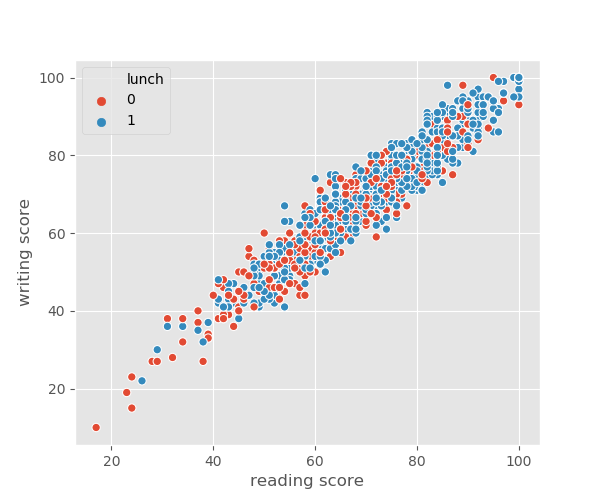

In [17]:
plt.figure()
sns.scatterplot(x="reading score", y="writing score", hue="lunch",
                data=studperf)

<IPython.core.display.Javascript object>


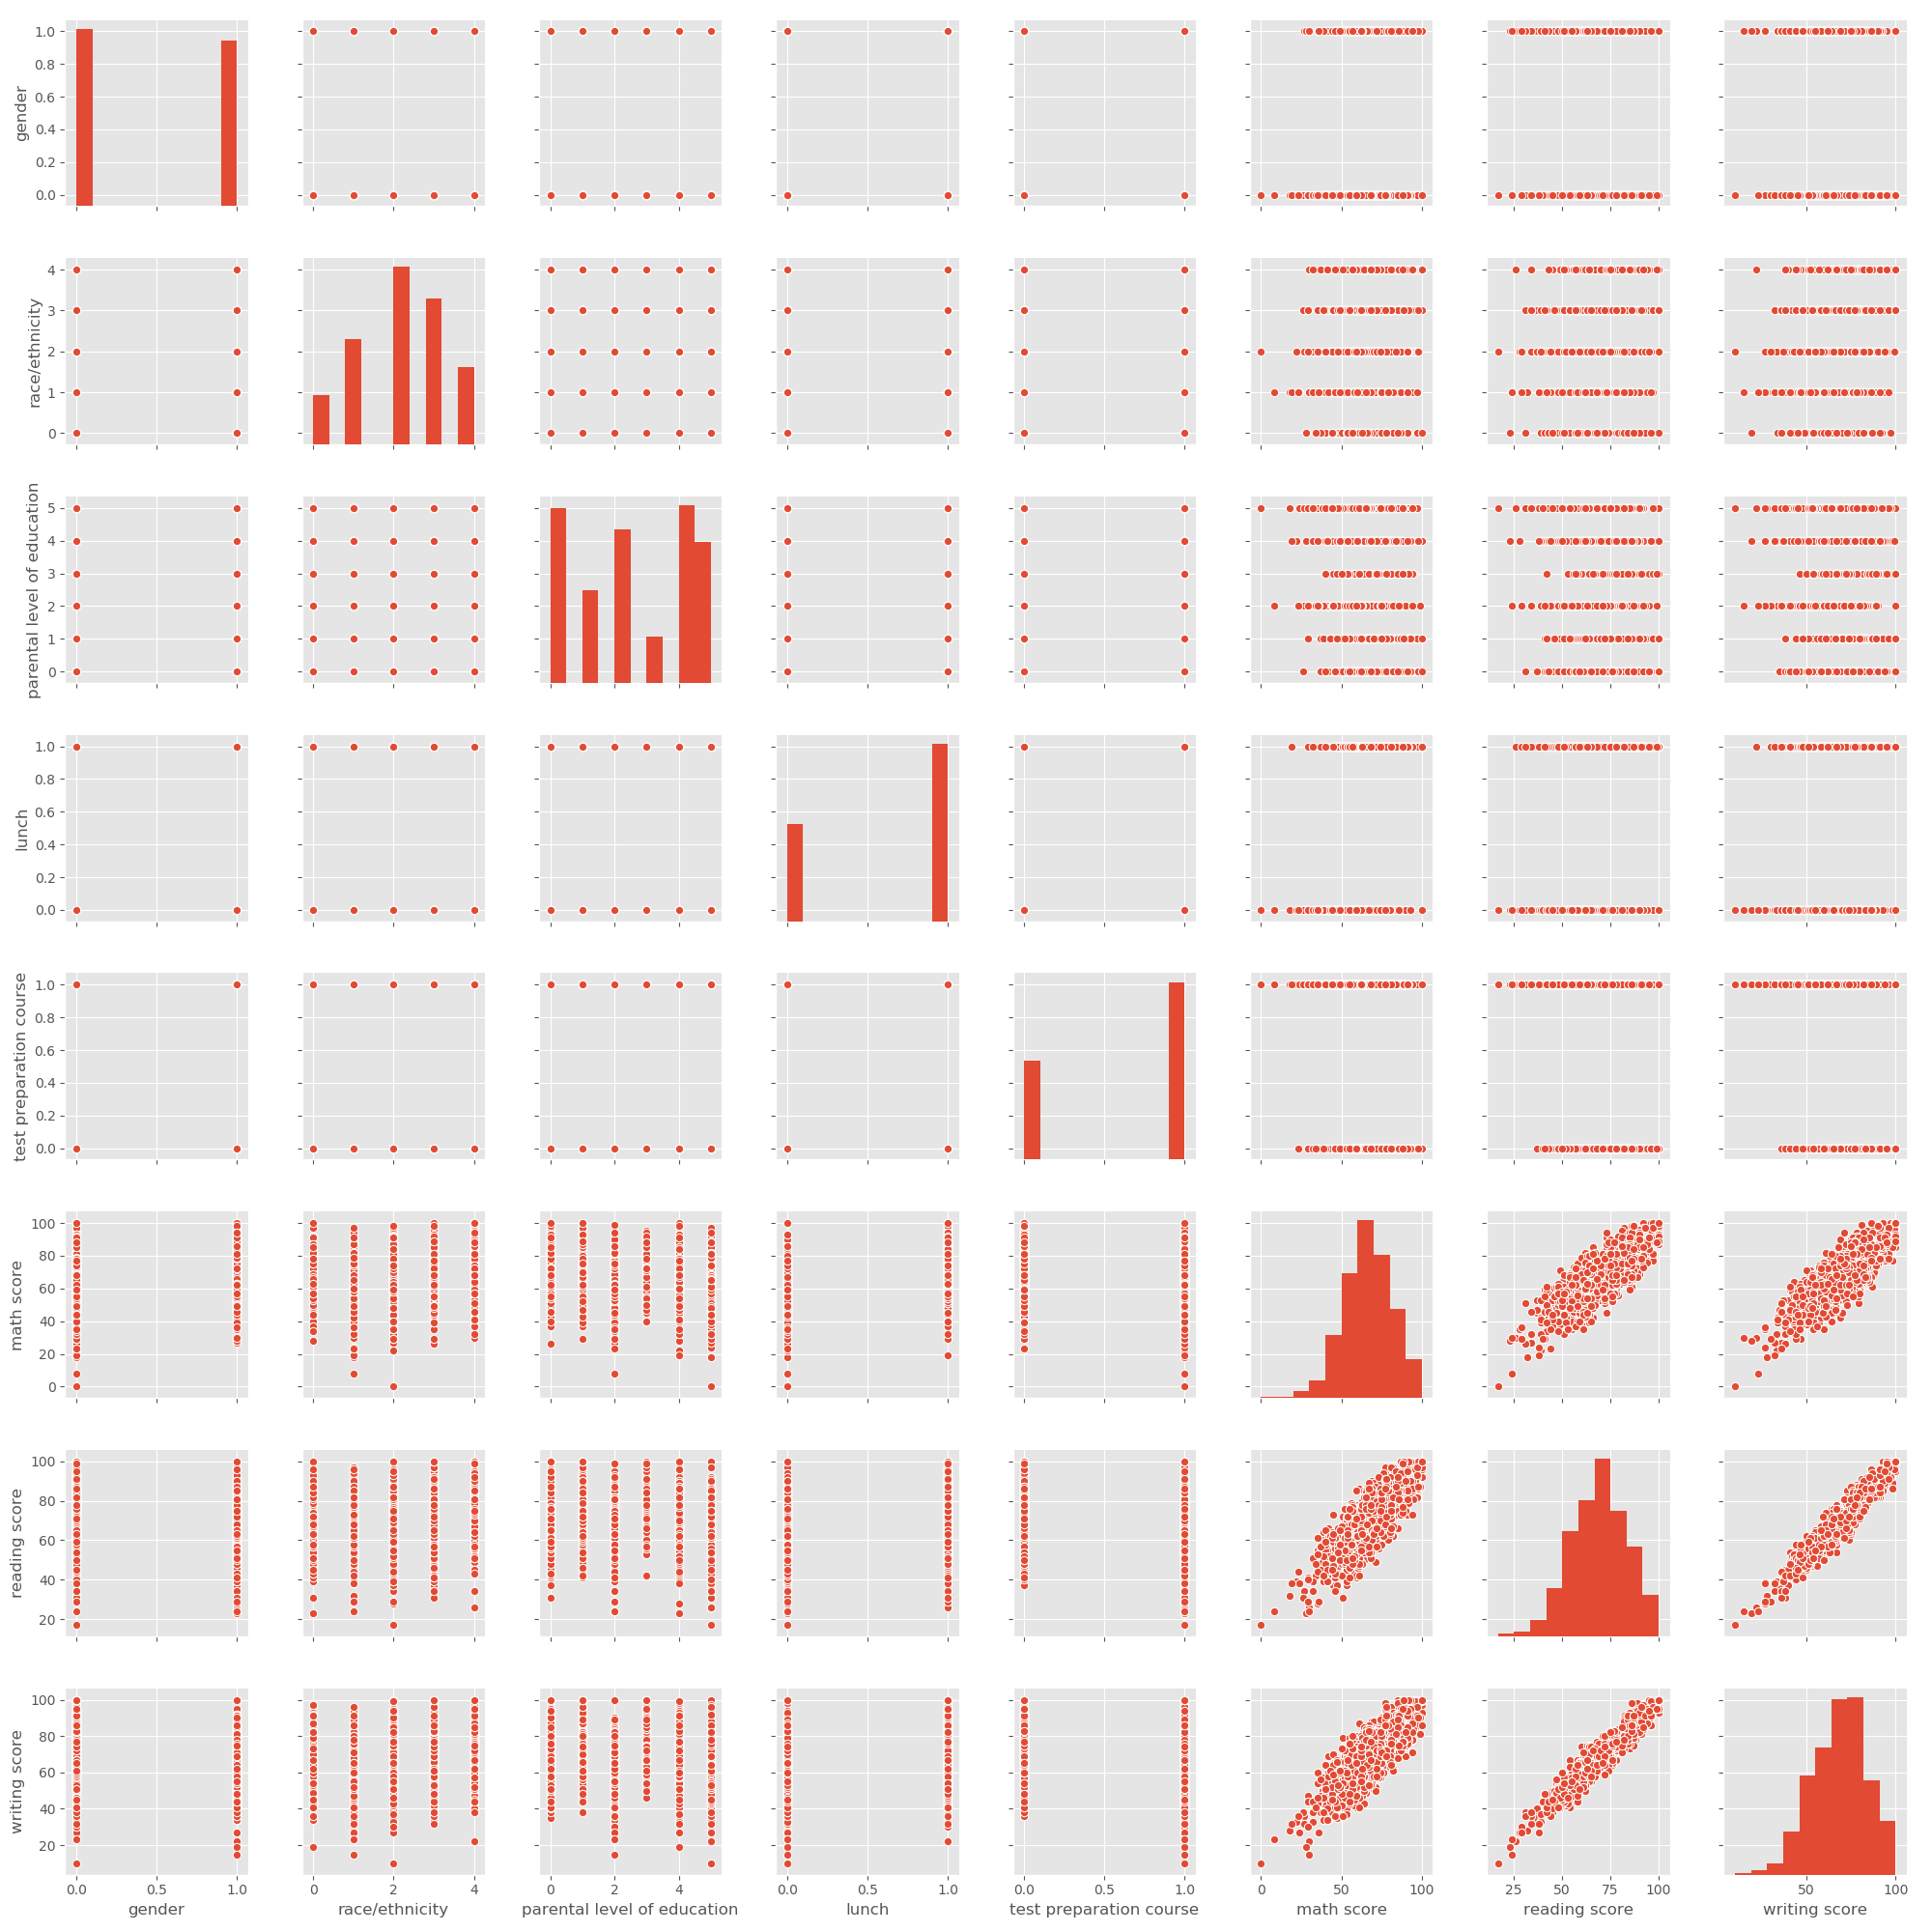

In [21]:
sns.pairplot(studperf)

In [25]:
happiness = pd.read_csv('./datasets/happiness/2017.csv', index_col=0)

In [26]:
happiness.head()

,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
Country,,,,,,,,,,,
Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707
Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715
Switzerland,4,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716
Finland,5,7.469,7.527542,7.410458,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182


<IPython.core.display.Javascript object>


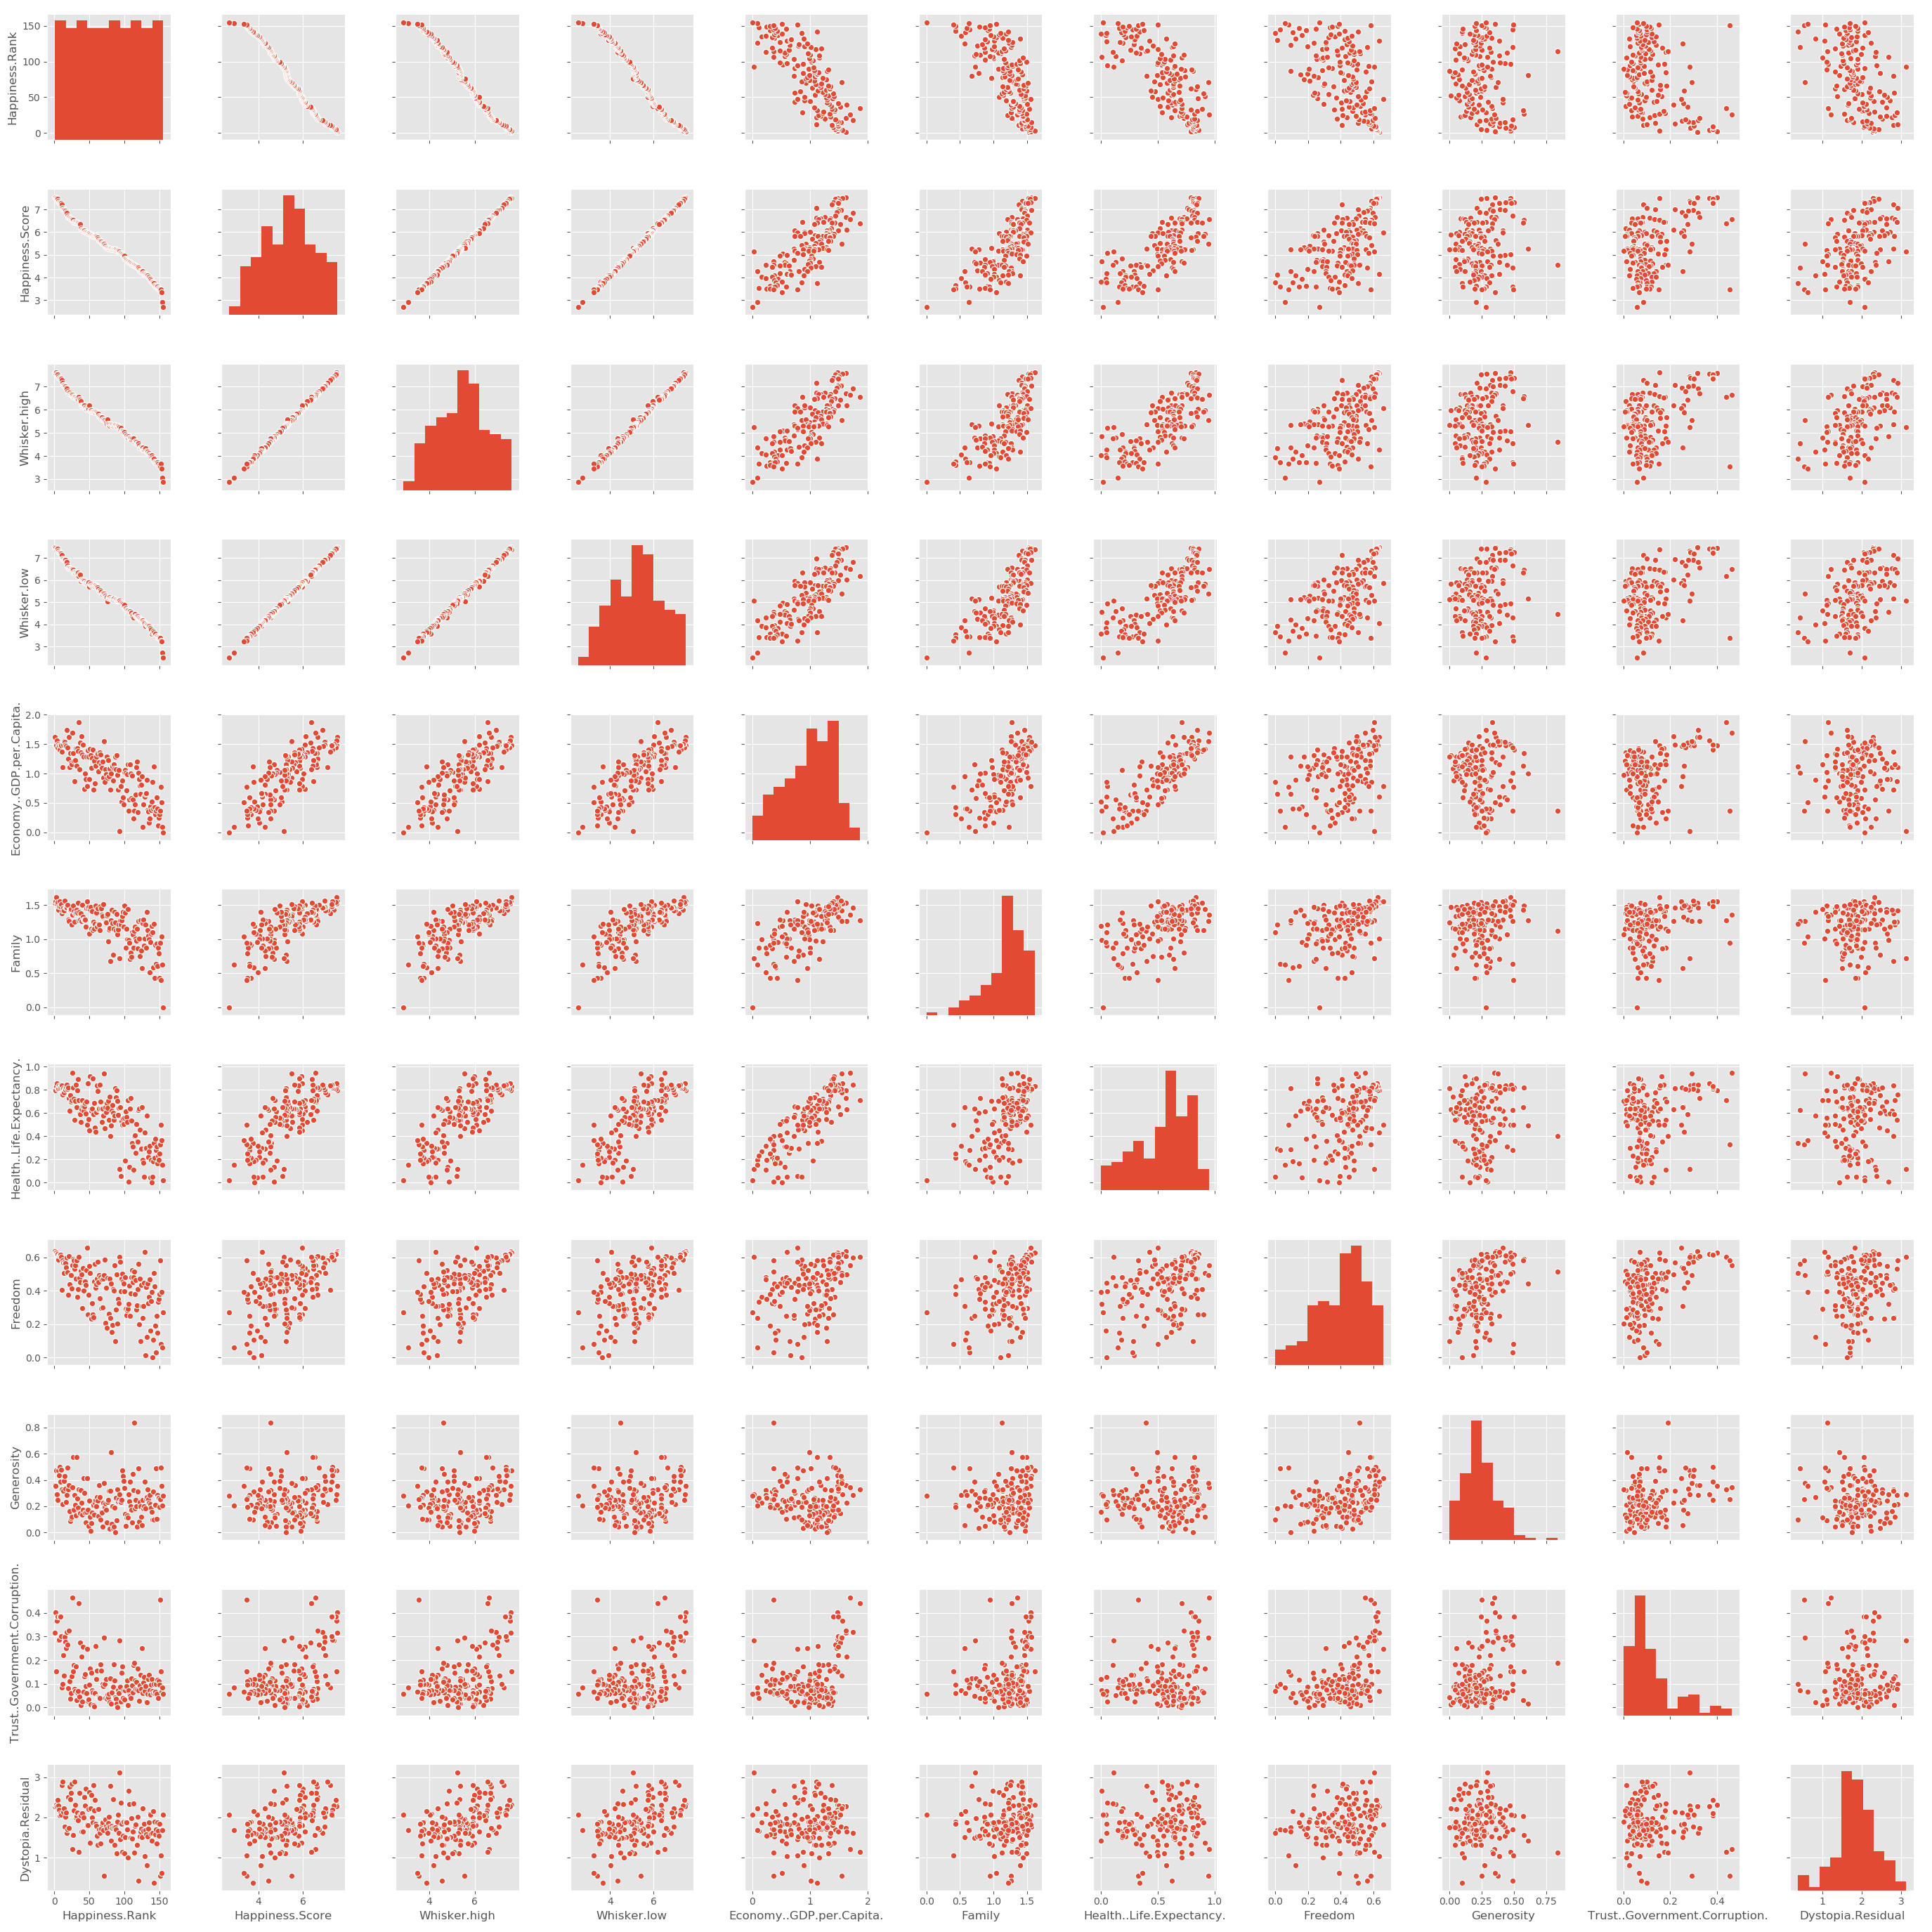

In [27]:
sns.pairplot(happiness)

In [30]:
df_house = pd.read_csv('./datasets/kc_house_data.csv', index_col = 0)

In [31]:
df_house.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,,,,,,,,,,,,,,,,,,,,
7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [53]:
np.log(1 + df_house['price'])

id
7129300520    12.309987
6414100192    13.195616
5631500400    12.100718
2487200875    13.311331
1954400510    13.142168
7237550310    14.018452
1321400060    12.458779
2008000270    12.583999
2414600126    12.343663
3793500160    12.685411
1736800520    13.403777
9212900260    13.056226
114101516     12.644331
6054650070    12.899222
1175000570    13.180634
9297300055    13.384729
1875500060    12.886644
6865200140    13.091906
16000397      12.149508
7983200060    12.345839
6300500875    12.861001
2524049179    14.508658
7137970340    12.560248
8091400200    12.439962
3814700200    12.703816
1202000200    12.358798
1794500383    13.750440
3303700376    13.410547
5101402488    12.989976
1873100390    13.485618
                ...    
2025049203    12.899097
952006823     12.847929
3832050760    12.506181
2767604724    13.132316
6632300207    12.861001
2767600688    12.934831
7570050450    12.758523
7430200100    14.016409
4140940150    13.256896
1931300412    13.071072
8672200110   

<IPython.core.display.Javascript object>


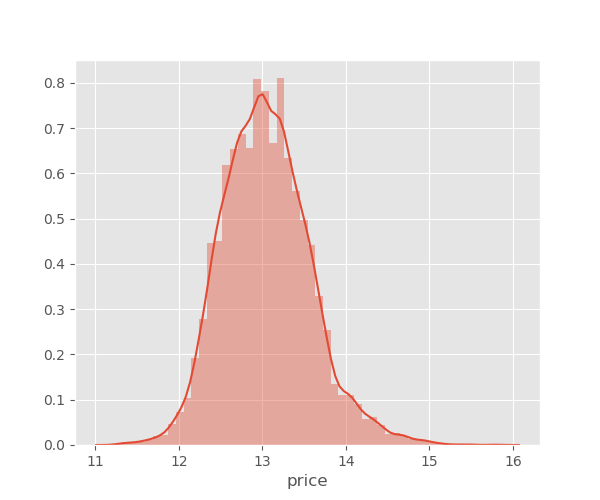

In [55]:
plt.figure()
sns.distplot(np.log(df_house['price']))

In [60]:
!{sys.executable} -m pip install patsy

In [61]:
import statsmodels.api as sm

In [62]:
import scipy.stats as stats

In [79]:
stats.boxcox(df_house['price'])[0]

array([0.13448597, 0.13448597, 0.13448597, ..., 0.13448597, 0.13448597,
       0.13448597])

In [65]:
df_house['price']

id
7129300520     221900.0
6414100192     538000.0
5631500400     180000.0
2487200875     604000.0
1954400510     510000.0
7237550310    1225000.0
1321400060     257500.0
2008000270     291850.0
2414600126     229500.0
3793500160     323000.0
1736800520     662500.0
9212900260     468000.0
114101516      310000.0
6054650070     400000.0
1175000570     530000.0
9297300055     650000.0
1875500060     395000.0
6865200140     485000.0
16000397       189000.0
7983200060     230000.0
6300500875     385000.0
2524049179    2000000.0
7137970340     285000.0
8091400200     252700.0
3814700200     329000.0
1202000200     233000.0
1794500383     937000.0
3303700376     667000.0
5101402488     438000.0
1873100390     719000.0
                ...    
2025049203     399950.0
952006823      380000.0
3832050760     270000.0
2767604724     505000.0
6632300207     385000.0
2767600688     414500.0
7570050450     347500.0
7430200100    1222500.0
4140940150     572000.0
1931300412     475000.0
8672200110   

<IPython.core.display.Javascript object>


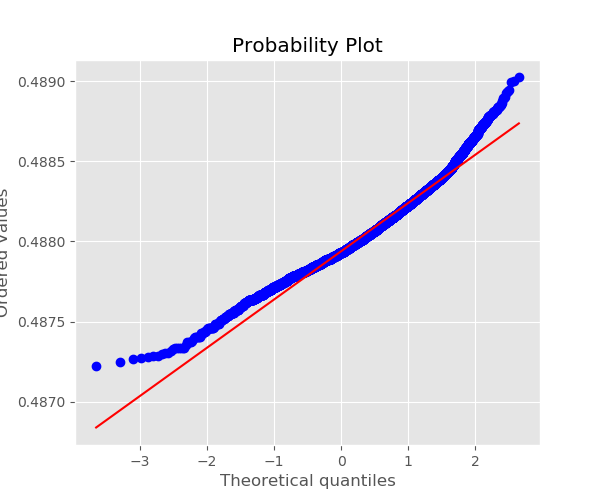

In [83]:
fig = plt.figure()
ax = fig.add_subplot(111)
# >>> x = stats.loggamma.rvs(c=2.5, size=500)
res = stats.probplot(stats.boxcox(np.log(df_house['price']))[0], dist=stats.loggamma, sparams=(2.5,), plot=ax)
# >>> ax.set_title("Probplot for loggamma dist with shape parameter 2.5")

In [50]:
sns.pairplot(df_house, vars=['long', 'lat', 'view', 'bathrooms', 'sqft_above'], hue='price', diag_kind='hist')

<IPython.core.display.Javascript object>

KeyboardInterrupt: 

In [13]:
null_columns = studperf.columns[studperf.isnull().any()]
print(null_columns)

Index([], dtype='object')


In [ ]:
black_friday = pd.read_csv('./datasets/BlackFriday.csv')

In [ ]:
black_friday.head()

In [ ]:
# В каких столбцах есть NaN?
null_columns = black_friday.columns[black_friday.isnull().any()]
print(null_columns)

In [ ]:
# заменим недостающие категории продуктов нулями
black_friday.fillna(value=0, inplace=True)

In [ ]:
black_friday.head()

In [ ]:
black_friday.City_Category.value_counts().values

In [ ]:
black_friday[['Marital_Status', 'Gender']] = black_friday[['Marital_Status', 'Gender']].apply(LabelEncoder().fit_transform)

In [ ]:
black_friday.head()

In [ ]:
# Построим распределение пары признаков
plt.figure()
sns.scatterplot(x="Marital_Status", y="Gender", hue="Purchase",
                data=black_friday)


In [ ]:

algorithms.append(KMeans(n_clusters=10, random_state=1))
algorithms.append(AffinityPropagation())
algorithms.append(SpectralClustering(n_clusters=10, random_state=1,
                                     affinity='nearest_neighbors'))
algorithms.append(AgglomerativeClustering(n_clusters=10))

data = []
for algo in algorithms:
    algo.fit(X)
    data.append(({
        'ARI': metrics.adjusted_rand_score(y, algo.labels_),
        'AMI': metrics.adjusted_mutual_info_score(y, algo.labels_),
        'Homogenity': metrics.homogeneity_score(y, algo.labels_),
        'Completeness': metrics.completeness_score(y, algo.labels_),
        'V-measure': metrics.v_measure_score(y, algo.labels_),
        'Silhouette': metrics.silhouette_score(X, algo.labels_)}))

results = pd.DataFrame(data=data, columns=['ARI', 'AMI', 'Homogenity

In [ ]:
black_friday['User_ID'].isnull()